# Study 269 -- Baltic-Dry
## For the curious: does the cost of shipping iron ore tell you where stocks are headed?

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

---

The **Baltic Dry Index (BDI)** measures what it costs to ship dry bulk commodities --
iron ore, coal, grain -- across the world's oceans. Because that freight is booked to
move *physical* stuff, and because the global fleet is fixed in the short run, the BDI
is often sold as a "pure", un-gameable thermometer of real global demand.

The folk wisdom: when freight rates are rising, the world economy is heating up, so the
stock market should follow. **Does the Baltic Dry shipping index lead the stock market?**


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from baltic_dry import data, strategy as st

# Real tape is built offline from the curated BDI x Shiller S&P (no network).
try:
    df = data.fetch_real(fetch=False)
    sig = st.bdi_signal(df, lookback=3)
    fwd = st.forward_sp_return(df)
    HAVE_REAL = len(df) > 100
except Exception as e:
    df = sig = fwd = None
    HAVE_REAL = False
    print("No real tape:", e)

if HAVE_REAL:
    print(f"Real tape: {df.shape[0]} months  {df.index[0].date()} -> {df.index[-1].date()}")
else:
    print("Real tape unavailable -- frozen headline numbers from R dict will be used")


Real tape: 497 months  1985-01-31 -> 2026-05-31


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 493, 'fp': '754cb2059bb5', 'reg_beta': 0.031, 'reg_t': 2.82, 'reg_r2': 0.0452, 'reg_ex2008_beta': 0.0106, 'reg_ex2008_t': 1.35, 'reg_ex2008_n': 469, 'sub1_beta': -0.0591, 'sub1_t': -1.41, 'sub1_n': 177, 'sub2_beta': 0.0541, 'sub2_t': 5.08, 'sub2_n': 120, 'sub3_beta': 0.019, 'sub3_t': 2.28, 'sub3_n': 196, 'bh_ann': 9.86, 'bh_t': 4.38, 'bh_sr': 0.8, 'bh_dd': -50.8, 'tim_ann': 6.6, 'tim_t': 3.97, 'tim_sr': 0.76, 'tim_dd': -43.7, 'tim_gross_ann': 6.62, 'exc_ann': -3.26, 'exc_t': -1.9, 'hit': 0.5456, 'base_rate': 0.6471, 'n_switch': 21, 'cost_bps': 0.21, 'syn0_beta': -0.008, 'syn0_t': -1.07, 'syn3_beta': 0.086, 'syn3_t': 10.55, 'syn6_beta': 0.182, 'syn6_t': 17.5}


## The picture: freight rates and the S&P, side by side

> 💡 *Note on the data:* the official BDI is a licensed Baltic Exchange product with no
clean free feed, so the real tape here pairs a **curated monthly reconstruction** of the
index (anchored to widely reported public levels, log-interpolated between them) with
monthly S&P 500 closes. It reproduces the index's shape and order of magnitude -- the
2008 super-spike, the GFC crash, the 2016 trough, the 2021 rebound -- but it is not the
daily fixing. Treat the numbers as indicative.


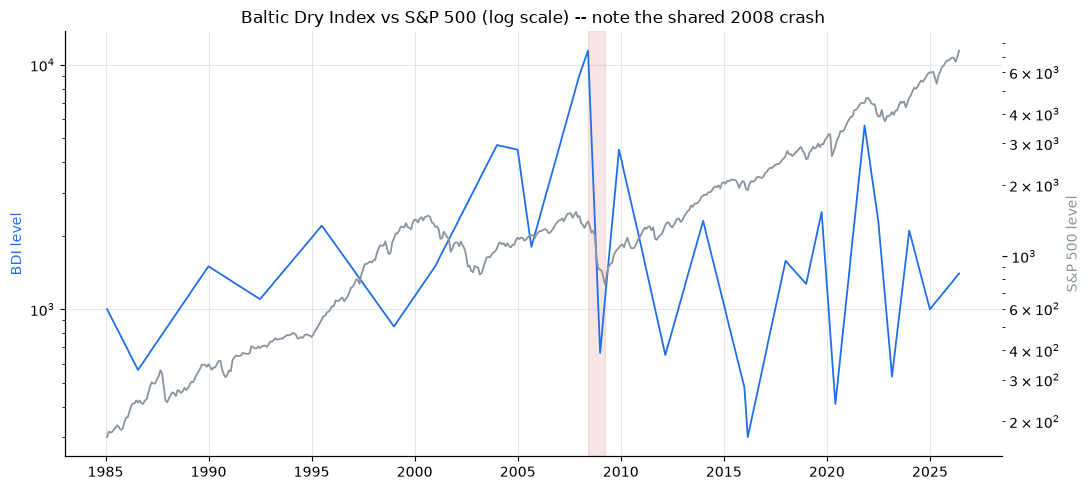

The shaded band is the 2008-09 crisis -- keep an eye on it, it does almost all the work.


In [3]:
fig, ax1 = plt.subplots(figsize=(11, 5))
if HAVE_REAL:
    ax1.plot(df.index, df["bdi"], color="#1f6feb", lw=1.3, label="Baltic Dry Index (curated)")
    ax1.set_ylabel("BDI level", color="#1f6feb")
    ax1.set_yscale("log")
    ax2 = ax1.twinx()
    ax2.plot(df.index, df["sp500"], color=GREY, lw=1.3, label="S&P 500")
    ax2.set_ylabel("S&P 500 level", color=GREY)
    ax2.set_yscale("log")
    ax2.grid(False)
    ax1.set_title("Baltic Dry Index vs S&P 500 (log scale) -- note the shared 2008 crash")
    # mark the 2008 peak->crash
    ax1.axvspan(pd.Timestamp("2008-05-31"), pd.Timestamp("2009-03-31"), color=RED, alpha=0.12)
else:
    ax1.text(0.5, 0.5, "Real tape unavailable (frozen numbers used below)",
             ha="center", va="center", transform=ax1.transAxes, fontsize=12, color=GREY)
plt.tight_layout()
plt.savefig("../docs/levels.png", dpi=120, bbox_inches="tight")
plt.show()
print("The shaded band is the 2008-09 crisis -- keep an eye on it, it does almost all the work.")


## Does a rising BDI predict a rising market next month?

The clean test: at each month-end, measure how much the BDI has moved over the last
3 months, then see whether that predicts the S&P's return *next* month (a full month
of lag, so it is genuinely a forecast, not a coincidence).


In [4]:
if HAVE_REAL:
    reg = st.predictive_regression(sig, fwd)
    print(f"Next-month S&P return on 3M BDI momentum:")
    print(f"  slope = {reg['beta']:+.4f}   HAC t = {reg['tstat']:+.2f}   R^2 = {reg['r2']:.3f}   n = {reg['n']}")
else:
    print(f"Frozen: slope = {R['reg_beta']:+.4f}   HAC t = {R['reg_t']:+.2f}   R^2 = {R['reg_r2']:.3f}")
print()
print(f"A HAC t of +{R['reg_t']:.2f} clears the usual 't >= 2' bar... but hold on.")


Next-month S&P return on 3M BDI momentum:
  slope = +0.0310   HAC t = +2.82   R^2 = 0.045   n = 493

A HAC t of +2.82 clears the usual 't >= 2' bar... but hold on.


## The catch: it is a 2008 mirage

The whole headline rests on one episode. In late 2008, freight rates **and** the stock
market collapsed *together* -- the BDI fell ~95% and the S&P halved. That single shared
crash is what makes the regression look predictive. Strip the 2008-09 crisis out and the
relationship evaporates.


In [5]:
if HAVE_REAL:
    mask = ~((df.index.year >= 2008) & (df.index.year <= 2009))
    rex = st.predictive_regression(sig[mask], fwd[mask])
    full_t = st.predictive_regression(sig, fwd)["tstat"]
    print(f"Full sample   : HAC t = {full_t:+.2f}")
    print(f"Ex-2008/09    : HAC t = {rex['tstat']:+.2f}   <- drops below the bar")
else:
    print(f"Full sample   : HAC t = {R['reg_t']:+.2f}")
    print(f"Ex-2008/09    : HAC t = {R['reg_ex2008_t']:+.2f}   <- drops below the bar")
print()
print("Remove one crisis and the 'leading indicator' stops leading.")


Full sample   : HAC t = +2.82
Ex-2008/09    : HAC t = +1.35   <- drops below the bar

Remove one crisis and the 'leading indicator' stops leading.


## And you cannot trade it anyway

Suppose you tried the obvious strategy: **stay long the S&P when freight is rising, sit
in cash when it is falling.** Does dodging the down-freight months help?


<>:9: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:9: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\loutr\AppData\Local\Temp\ipykernel_6712\972661968.py:9: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  ax.set_yscale("log"); ax.set_ylabel("Growth of \$1 (log)")


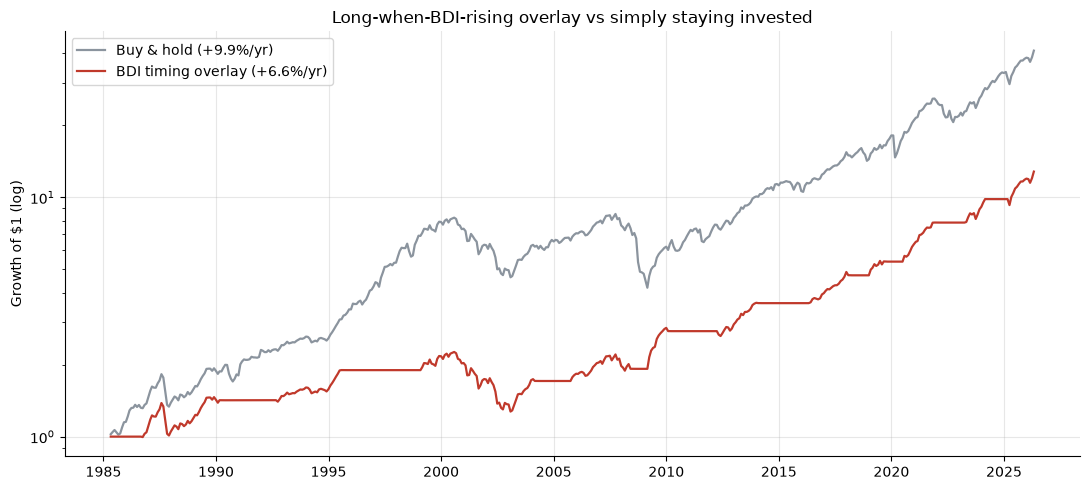

Buy & hold: +9.86%/yr   Timing: +6.60%/yr

The overlay GIVES UP 3.3%/yr vs buy & hold -- it sits out too many good months.


In [6]:
if HAVE_REAL:
    tim = st.timing_returns(sig, fwd, one_way_bps=5.0)
    s_bh = st.summarize(tim["buy_hold"]); s_n = st.summarize(tim["timing_net"])
    cum_bh = (1 + tim["buy_hold"]).cumprod()
    cum_tm = (1 + tim["timing_net"]).cumprod()
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(cum_bh.index, cum_bh.values, color=GREY, lw=1.6, label=f"Buy & hold ({s_bh['mean']*12*100:+.1f}%/yr)")
    ax.plot(cum_tm.index, cum_tm.values, color=RED, lw=1.6, label=f"BDI timing overlay ({s_n['mean']*12*100:+.1f}%/yr)")
    ax.set_yscale("log"); ax.set_ylabel("Growth of \$1 (log)")
    ax.set_title("Long-when-BDI-rising overlay vs simply staying invested")
    ax.legend()
    plt.tight_layout(); plt.savefig("../docs/equity_curve.png", dpi=120, bbox_inches="tight"); plt.show()
    print(f"Buy & hold: {s_bh['mean']*12*100:+.2f}%/yr   Timing: {s_n['mean']*12*100:+.2f}%/yr")
else:
    print(f"Buy & hold: {R['bh_ann']:+.2f}%/yr   Timing: {R['tim_ann']:+.2f}%/yr")
print(f"\nThe overlay GIVES UP {abs(R['exc_ann']):.1f}%/yr vs buy & hold -- it sits out too many good months.")


## The bottom line for the curious

The Baltic Dry Index is a genuinely useful gauge of *shipping* -- but as a stock-market
crystal ball it is folklore:

- The "predictive" *t*-stat (+2.82) is almost entirely the **2008 co-crash**;
  strip the crisis and it falls to +1.35.
- The relationship is **negative** in the 1980s-90s -- the sign is not even stable.
- Guessing next month's direction from the BDI is right only 55% of the
  time -- *worse* than always betting "up" (65%).
- The tradable version **loses 3.3%/yr** to just staying invested.

A **Weak / Mirage** signal: the BDI moves *with* the world economy, but it does not
reliably move *ahead* of the stock market, and you cannot make money trying.


*Desk verdict: **Weak / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md) for full numbers.*